# prep

In [ ]:
import os
os.chdir('E:/GitHubProjects/autolabeling_time_series_data/')

from typing import Literal, Callable
import numpy as np
import pandas as pd
pd.set_option('display.max_colwidth', 150)

from src.utils.parse_UCR import load_UCR
from src.utils.transform_tools import split_train_test
from src.utils.visuals import plot_series, plot_series_grid

from src.clustering.partitioning_clustering import Sklearn_kmeans_model
from src.clustering.density_clustering import BIRCH_model, DBSCAN_model
from src.clustering.hierarchical_clustering import AC_model

from sklearn.preprocessing import StandardScaler

from src.feature_extraction.manual_methods.TS_feature_extractor import TS_feature_extractor, Feature_extraction_method, Feature_extractor_pipeline
from src.feature_extraction.manual_methods.feature_extraction import (
    tsa_detrend, 
    tsa_acf,
    statistical_features,
    paa_features,
    signal_peaks_features,
    stft_features,
    dft_components,
    dft_signal,
    dft_approximation,
    dwt_features,
    dwt_signal, 
    stl_decomposition,
    stl_features
)

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [2]:
def prepare_data(dataset_name, split_ratio=0.8):
    X, y, metadata = load_UCR(dataset_name)
    X_train, X_test, y_train, y_test = split_train_test(X, y, split_ratio, 42)
    X_train = X_train.squeeze(1)
    X_test = X_test.squeeze(1)
    
    print(X_train.shape, X_test.shape)
    print(np.unique(y_train))
    print(pd.Series(y_train).value_counts(normalize=True))
    print(pd.Series(y_test).value_counts(normalize=True))
    
    return X_train, X_test, y_train, y_test


def visualize_clusters(X, y, save_path):
    for val in np.unique(y):
        plot_series(X[y == val].tolist(), show_legend=False, plot_title=f'Cluster {val}', save_path=f"{save_path}/Cluster {val}.png")


def use_scaler(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled


def make_pipeline(X, prep_funcs):
    X_prep = []
    for row in X:
        new_row = row.copy()
        for prep_func in prep_funcs:
            prep_model = TS_feature_extractor(prep_func)
            res = prep_model.extract(new_row)
            new_row = res
        X_prep.append(new_row)  
    return np.asarray(X_prep)


def get_segments(data: np.ndarray, n_segments: int = None, segment_size: int = None) -> list:
    length = len(data)

    if n_segments is not None:
        segment_size = length // n_segments
    elif segment_size is not None:
        n_segments = length // segment_size
    else:
        raise ValueError("Укажите либо n_segments, либо segment_size")

    remainder = length % n_segments
    if remainder != 0:
        print(f"Длина массива не делится на {n_segments}, последние {remainder} элементов будут проигнорированы.")

    segments = []
    for i in range(n_segments):
        start = i * segment_size
        end = start + segment_size
        segments.append(data[start:end])

    return segments


def make_segm_pipeline(X, prep_funcs, n_segments, segm_use:list=None):
    X_prep = []
    if segm_use is None:
        segm_use = list(range(n_segments))
        
    for row in X:
        new_row = row.copy()
        segments = [item for inx, item in enumerate(get_segments(new_row, n_segments)) if inx in segm_use]
        res = make_pipeline(segments, prep_funcs)
        new_row = np.concatenate(res)
    X_prep.append(new_row)  
    return np.asarray(X_prep)



def get_model(model_name:Literal['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative'], X, y):
    
    if model_name == 'dbscan':
        model = DBSCAN_model()
        result_df = model.evaluate_results(X, y, config_path=f'configs/parameters_search/{model_name}.yaml', search_method='grid_search')

    if model_name == 'birch':
        model = BIRCH_model()
        result_df = model.evaluate_results(X, y, config_path=f'configs/parameters_search/{model_name}.yaml', search_method='grid_search')

    if model_name == 'sklearn_kmeans':
        model = Sklearn_kmeans_model()
        result_df = model.evaluate_results(X, y, config_path=f'configs/parameters_search/{model_name}.yaml', search_method='grid_search')

    if model_name == 'agglomerative':
        model = AC_model()
        result_df = model.evaluate_results(X, y, config_path=f'configs/parameters_search/{model_name}.yaml', search_method='grid_search')

    return result_df

def visualize_latent_space(train_latents, train_labels, model_save_path):
    """
    Визуализация латентного пространства с помощью t-SNE.
    Объединяет train и val для проецирования, но различает их на графике.
    """

    # Объединяем все данные для t-SNE
    combined = np.concatenate([train_latents], axis=0)
    labels_combined = np.concatenate([train_labels], axis=0)

    # Создаем маски для train/val
    train_mask = np.array([True]*train_latents.shape[0])
    # Применяем t-SNE ко всем данным сразу
    tsne = TSNE(n_components=2, random_state=42, init='random', perplexity=30)
    latents_2d = tsne.fit_transform(combined)

    # Разделяем результаты обратно
    train_2d = latents_2d[train_mask]

    # Визуализация
    plt.figure(figsize=(12, 8))

    # Точки из train
    scatter_train = plt.scatter(train_2d[:, 0], train_2d[:, 1], 
                                c=train_labels, cmap='tab10', s=60, 
                                label='Train', edgecolor='k', alpha=0.7)

    # Легенда
    unique_labels = np.unique(labels_combined)
    handles, _ = scatter_train.legend_elements(prop="colors", num=len(unique_labels))
    plt.legend(handles, unique_labels, title="Classes")

    plt.title("Latent Space Visualization (t-SNE) - Train")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True)
    plt.tight_layout()
    if model_save_path is not None:
        plt.savefig(model_save_path)
        plt.close()
    else:
        plt.show()



# synthetic 

In [3]:
from src.generation.ts_generators import *  
from src.generation.ts_noise_generators import *  
from src.generation.ts_creation import *
from src.utils import plot_series, plot_series_grid

In [4]:
clusters_num = 2
step = 0.05
sample_q = 100
trend_config = 'configs/trends/linear_trend2_101.yaml'


trend_gen = TS_generator(linear_trend, trend_config)

grid = np.linspace(trend_gen.config['slope_d'], trend_gen.config['slope_u'], clusters_num)

X_train = []
lbls = []

for inx, item in enumerate(grid):
    print(inx, item)
    trend_gen.config['slope_d'] = item - step
    trend_gen.config['slope_u'] = item + step
    trend_gen.config['slope_q'] = 1
    
    sample = trend_gen.generate()[0]
    noise = Noise_generator(sample, normal_noise, 'configs/noise/normal_05.yaml')
    
    for _ in range(int(sample_q/clusters_num)):
        cl1 = TS_merger()
        block1 = TS_block(trend=trend_gen, noise=noise)
        cl1.add_block(block1)

        X_train.append(cl1.generate())
         
    lbls += [inx+1] * int(sample_q/clusters_num)

X_train = np.array(X_train)
lbls = np.array(lbls)

print(X_train.shape, lbls.shape)

0 0.01
1 0.1
(100, 100) (100,)


In [5]:
# methods = [Feature_extraction_method(statistical_features, 'configs/manual_fe/statistical_features.yaml'), Feature_extraction_method(statistical_features, 'configs/manual_fe/tsa_detrend.yaml')]
methods = [Feature_extraction_method(tsa_detrend, 'configs/manual_fe/tsa_detrend.yaml')]
pipeline = Feature_extractor_pipeline(methods)

result = pipeline.batch_extract(X_train, 'grid')

In [6]:
f1_scores = []
nmi_scores = []
ari_scores = []
si_scores = []

y_train = lbls

for i, item in enumerate(result):
    res = get_model('sklearn_kmeans', item, y_train)
    # visualize_latent_space(result[0], y_train, 'experiments/manual_methods/Chinatown/no_techniques.png')
    si_scores.append(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).iloc[0,-1])
    nmi_scores.append(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).iloc[0,-1])
    ari_scores.append(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).iloc[0,-1])
    f1_scores.append(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).iloc[0,-1])

plot_series_grid([f1_scores, nmi_scores, ari_scores, si_scores], ['f1_score', 'ARI', 'NMI', 'Silhouette_score'])

Grid Search Progress:   0%|          | 0/60 [00:00<?, ?it/s]


AttributeError: 'StandardScaler' object has no attribute 'normalize'

# real data

In [3]:
X_train, X_test, y_train, y_test = prepare_data('Chinatown')

fe_stl = Feature_extraction_method(stl_features, "configs/manual_fe/stl.yaml")
stats = Feature_extraction_method(statistical_features, 'configs/manual_fe/statistical_features.yaml')
pipeline = Feature_extractor_pipeline([fe_stl, stats])
# results = pipeline.extract_all(X_train[0])
results_grid = pipeline.batch_extract(X_train[:5], 'grid')
results_con = pipeline.batch_extract(X_train[:5], 'concat')

Old Classes: [1 2]
New Classes: [0 1]
(290, 24) (73, 24)
[0 1]
1    0.713793
0    0.286207
Name: proportion, dtype: float64
1    0.712329
0    0.287671
Name: proportion, dtype: float64


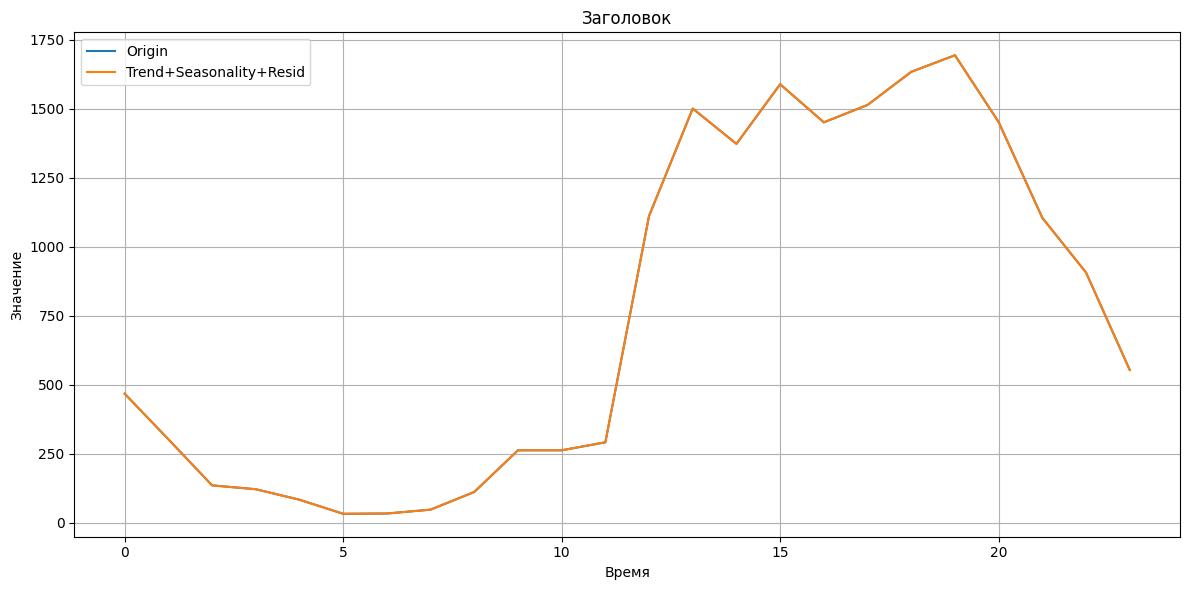

In [61]:
res_dec = stl_decomposition(X_train[0], period=4)
plot_series([X_train[0], res_dec[0]+res_dec[1]+res_dec[2]], ['Origin','Trend+Seasonality+Resid'])

In [20]:
results_grid[0][0][0] == np.concatenate([
results_con[0][0][:5], 
results_con[0][0][100:]])

result = pipeline.batch_extract(X_train, 'grid')[0]

(290, 11)


Grid Search Progress: 100%|██████████| 60/60 [00:03<00:00, 19.22it/s]


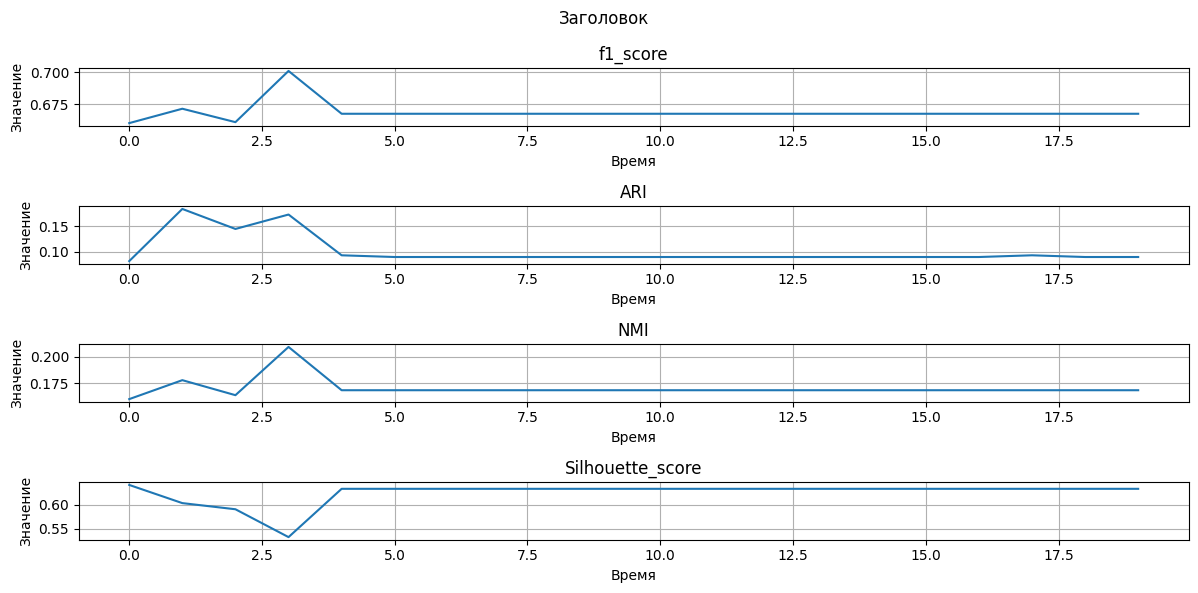

In [33]:
print(result[0].shape)

f1_scores = []
nmi_scores = []
ari_scores = []
si_scores = []

for i, item in enumerate(result):
    res = get_model('sklearn_kmeans', item, y_train)
    # visualize_latent_space(result[0], y_train, 'experiments/manual_methods/Chinatown/no_techniques.png')
    si_scores.append(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).iloc[0,-1])
    nmi_scores.append(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).iloc[0,-1])
    ari_scores.append(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).iloc[0,-1])
    f1_scores.append(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).iloc[0,-1])

plot_series_grid([f1_scores, nmi_scores, ari_scores, si_scores], ['f1_score', 'ARI', 'NMI', 'Silhouette_score'])

In [35]:
X_train, X_test, y_train, y_test = prepare_data('MelbournePedestrian')
len([np.mean(X_train[y_train == y_val], axis=0) for y_val in np.unique(y_train)]), len(np.unique(y_train).tolist())
# np.mean(X_train, axis=2)
# plot_series(np.array([np.mean(X_train[y_train == y_val], axis=0) for y_val in np.unique(y_train)]), np.unique(y_train).tolist())
# print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head(1))
# print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head(1))
# print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head(1))
# print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head(1))


Old Classes: [ 1  2  3  4  5  6  7  8  9 10]
New Classes: [0 1 2 3 4 5 6 7 8 9]
(2765, 24) (692, 24)
[0 1 2 3 4 5 6 7 8 9]
3    0.105244
4    0.104882
9    0.104882
6    0.104882
0    0.104882
5    0.103797
1    0.103074
2    0.098011
7    0.086799
8    0.083544
Name: proportion, dtype: float64
9    0.105491
0    0.105491
6    0.105491
4    0.105491
5    0.104046
3    0.104046
1    0.102601
2    0.098266
7    0.086705
8    0.082370
Name: proportion, dtype: float64


(10, 10)

In [14]:
X_train, X_test, y_train, y_test = prepare_data('Chinatown')

# X_train = use_scaler(X_train)
# X_test = use_scaler(X_test)

visualize_clusters(X_train, y_train, 'experiments/manual_methods/Chinatown')

res = get_model('sklearn_kmeans', X_train, y_train)
visualize_latent_space(X_train, y_train, 'experiments/manual_methods/Chinatown/no_techniques.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())

X_train_new = make_pipeline(X_train, [tsa_detrend])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/Chinatown/detrend.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())

X_train_new = make_pipeline(X_train, [tsa_detrend, dft_signal])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/Chinatown/detrend_dft_components.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())


Old Classes: [1 2]
New Classes: [0 1]
(290, 24) (73, 24)
[0 1]
1    0.713793
0    0.286207
Name: proportion, dtype: float64
1    0.712329
0    0.287671
Name: proportion, dtype: float64


Grid Search Progress: 100%|██████████| 60/60 [00:03<00:00, 17.21it/s]


                                                                 parameter  \
0     {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}   
99   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   
459     {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}   
450      {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 5}   
369     {'init': 'random', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   

         metric     value  
0    silhouette  0.463283  
99   silhouette  0.463283  
459  silhouette  0.463283  
450  silhouette  0.463283  
369  silhouette  0.463283  
                                                                 parameter  \
75    {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 6, 'n_init': 5}   
174  {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 6, 'n_init': 15}   
246  {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 5, 'n_init': 15}   
66   {'init': 'k-means++', 'max_iter': 100, 'n_clus

Grid Search Progress: 100%|██████████| 60/60 [00:03<00:00, 18.40it/s]


                                                                 parameter  \
0     {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}   
99   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   
459     {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}   
450      {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 5}   
369     {'init': 'random', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   

         metric     value  
0    silhouette  0.333424  
99   silhouette  0.333424  
459  silhouette  0.333424  
450  silhouette  0.333424  
369  silhouette  0.333424  
                                                                 parameter  \
3     {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}   
102  {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   
462     {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}   
453      {'init': 'random', 'max_iter': 300, 'n_clu

Grid Search Progress: 100%|██████████| 60/60 [00:03<00:00, 17.38it/s]


                                                                 parameter  \
0     {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}   
99   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   
459     {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}   
450      {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 5}   
369     {'init': 'random', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   

         metric     value  
0    silhouette  0.305999  
99   silhouette  0.305999  
459  silhouette  0.305999  
450  silhouette  0.305999  
369  silhouette  0.305999  
                                                                 parameter  \
381      {'init': 'random', 'max_iter': 200, 'n_clusters': 3, 'n_init': 5}   
300     {'init': 'random', 'max_iter': 100, 'n_clusters': 3, 'n_init': 15}   
201   {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 5}   
210  {'init': 'k-means++', 'max_iter': 300, 'n_clus

In [22]:
res#.metric.unique()

,parameter,metric,value
0,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}",silhouette,0.630510
1,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}",davies_bouldin_score,0.605933
2,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}",calinski_harabasz_score,6440.692877
3,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}",nmi,0.329896
4,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}",ari,0.134839
...,...,...,...
535,"{'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 15}",ari,0.294905
536,"{'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 15}",accuracy,0.030741
537,"{'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 15}",precision,0.031495
538,"{'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 15}",recall,0.030015


In [21]:
res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False)

,parameter,metric,value
0,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}",silhouette,0.630510
99,"{'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}",silhouette,0.630510
459,"{'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}",silhouette,0.630510
450,"{'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 5}",silhouette,0.630510
369,"{'init': 'random', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}",silhouette,0.630510
360,"{'init': 'random', 'max_iter': 200, 'n_clusters': 2, 'n_init': 5}",silhouette,0.630510
279,"{'init': 'random', 'max_iter': 100, 'n_clusters': 2, 'n_init': 15}",silhouette,0.630510
9,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 15}",silhouette,0.630510
189,"{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}",silhouette,0.630510
180,"{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2, 'n_init': 5}",silhouette,0.630510


In [18]:
X_train, X_test, y_train, y_test = prepare_data('MelbournePedestrian')

visualize_clusters(X_train, y_train, 'experiments/manual_methods/MelbournePedestrian')

res = get_model('sklearn_kmeans', X_train, y_train)
visualize_latent_space(X_train, y_train, 'experiments/manual_methods/MelbournePedestrian/no_techniques.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())

X_train_new = make_pipeline(X_train, [tsa_detrend])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/MelbournePedestrian/detrend.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())

X_train_new = make_pipeline(X_train, [tsa_detrend, dft_signal])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/MelbournePedestrian/detrend_dft_components.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())

X_train_new = make_pipeline(X_train, [signal_peaks_features])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/MelbournePedestrian/signal_peaks_features.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())


Old Classes: [ 1  2  3  4  5  6  7  8  9 10]
New Classes: [0 1 2 3 4 5 6 7 8 9]
(2765, 24) (692, 24)
[0 1 2 3 4 5 6 7 8 9]
3    0.105244
4    0.104882
9    0.104882
6    0.104882
0    0.104882
5    0.103797
1    0.103074
2    0.098011
7    0.086799
8    0.083544
Name: proportion, dtype: float64
9    0.105491
0    0.105491
6    0.105491
4    0.105491
5    0.104046
3    0.104046
1    0.102601
2    0.098266
7    0.086705
8    0.082370
Name: proportion, dtype: float64


Grid Search Progress: 100%|██████████| 60/60 [00:11<00:00,  5.14it/s]


                                                                 parameter  \
198   {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 5}   
18    {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 3, 'n_init': 5}   
477     {'init': 'random', 'max_iter': 300, 'n_clusters': 3, 'n_init': 15}   
207  {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 15}   
108   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 3, 'n_init': 5}   

         metric     value  
198  silhouette  0.566540  
18   silhouette  0.566540  
477  silhouette  0.565681  
207  silhouette  0.565681  
108  silhouette  0.565681  
                                                                 parameter  \
345      {'init': 'random', 'max_iter': 100, 'n_clusters': 6, 'n_init': 5}   
264  {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 6, 'n_init': 15}   
174  {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 6, 'n_init': 15}   
534     {'init': 'random', 'max_iter': 300, 'n_clus

Grid Search Progress: 100%|██████████| 60/60 [00:11<00:00,  5.28it/s]


                                                                 parameter  \
198   {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 5}   
108   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 3, 'n_init': 5}   
18    {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 3, 'n_init': 5}   
27   {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 3, 'n_init': 15}   
477     {'init': 'random', 'max_iter': 300, 'n_clusters': 3, 'n_init': 15}   

         metric     value  
198  silhouette  0.617216  
108  silhouette  0.617216  
18   silhouette  0.617216  
27   silhouette  0.617216  
477  silhouette  0.617216  
                                                                parameter  \
345     {'init': 'random', 'max_iter': 100, 'n_clusters': 6, 'n_init': 5}   
435     {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 5}   
75   {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 6, 'n_init': 5}   
534    {'init': 'random', 'max_iter': 300, 'n_clusters'

Grid Search Progress: 100%|██████████| 60/60 [00:12<00:00,  4.83it/s]


                                                                 parameter  \
198   {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 5}   
297     {'init': 'random', 'max_iter': 100, 'n_clusters': 3, 'n_init': 15}   
18    {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 3, 'n_init': 5}   
27   {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 3, 'n_init': 15}   
468      {'init': 'random', 'max_iter': 300, 'n_clusters': 3, 'n_init': 5}   

         metric     value  
198  silhouette  0.559079  
297  silhouette  0.559079  
18   silhouette  0.559079  
27   silhouette  0.559079  
468  silhouette  0.559079  
                                                                parameter  \
354    {'init': 'random', 'max_iter': 100, 'n_clusters': 6, 'n_init': 15}   
345     {'init': 'random', 'max_iter': 100, 'n_clusters': 6, 'n_init': 5}   
435     {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 5}   
534    {'init': 'random', 'max_iter': 300, 'n_clusters'

Grid Search Progress: 100%|██████████| 60/60 [00:11<00:00,  5.22it/s]


                                                                 parameter  \
0     {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}   
99   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   
459     {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}   
450      {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 5}   
369     {'init': 'random', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   

         metric    value  
0    silhouette  0.63051  
99   silhouette  0.63051  
459  silhouette  0.63051  
450  silhouette  0.63051  
369  silhouette  0.63051  
                                                                 parameter  \
444     {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 15}   
435      {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 5}   
525      {'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 5}   
165   {'init': 'k-means++', 'max_iter': 200, 'n_clusters'

In [ ]:
X_train, X_test, y_train, y_test = prepare_data('MelbournePedestrian')
X_train = use_scaler(X_train)

visualize_clusters(X_train, y_train, 'experiments/manual_methods/MelbournePedestrian_scaled')

res = get_model('sklearn_kmeans', X_train, y_train)
visualize_latent_space(X_train, y_train, 'experiments/manual_methods/MelbournePedestrian_scaled/no_techniques.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())

X_train_new = make_pipeline(X_train, [tsa_detrend])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/MelbournePedestrian_scaled/detrend.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())

X_train_new = make_pipeline(X_train, [tsa_detrend, dft_signal])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/MelbournePedestrian_scaled/detrend_dft_components.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())


X_train_new = make_pipeline(X_train, [signal_peaks_features])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/MelbournePedestrian_scaled/signal_peaks_features.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())


Old Classes: [ 1  2  3  4  5  6  7  8  9 10]
New Classes: [0 1 2 3 4 5 6 7 8 9]
(2765, 24) (692, 24)
[0 1 2 3 4 5 6 7 8 9]
3    0.105244
4    0.104882
9    0.104882
6    0.104882
0    0.104882
5    0.103797
1    0.103074
2    0.098011
7    0.086799
8    0.083544
Name: proportion, dtype: float64
9    0.105491
0    0.105491
6    0.105491
4    0.105491
5    0.104046
3    0.104046
1    0.102601
2    0.098266
7    0.086705
8    0.082370
Name: proportion, dtype: float64


Grid Search Progress: 100%|██████████| 60/60 [00:12<00:00,  4.87it/s]


                                                                 parameter  \
405     {'init': 'random', 'max_iter': 200, 'n_clusters': 4, 'n_init': 15}   
225  {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 4, 'n_init': 15}   
126   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 4, 'n_init': 5}   
135  {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 4, 'n_init': 15}   
27   {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 3, 'n_init': 15}   

         metric     value  
405  silhouette  0.507677  
225  silhouette  0.507091  
126  silhouette  0.507091  
135  silhouette  0.507091  
27   silhouette  0.506645  
                                                              parameter  \
444  {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 15}   
354  {'init': 'random', 'max_iter': 100, 'n_clusters': 6, 'n_init': 15}   
345   {'init': 'random', 'max_iter': 100, 'n_clusters': 6, 'n_init': 5}   
525   {'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_i

Grid Search Progress: 100%|██████████| 60/60 [00:12<00:00,  4.93it/s]


                                                                 parameter  \
396      {'init': 'random', 'max_iter': 200, 'n_clusters': 4, 'n_init': 5}   
495     {'init': 'random', 'max_iter': 300, 'n_clusters': 4, 'n_init': 15}   
405     {'init': 'random', 'max_iter': 200, 'n_clusters': 4, 'n_init': 15}   
135  {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 4, 'n_init': 15}   
126   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 4, 'n_init': 5}   

         metric     value  
396  silhouette  0.497733  
495  silhouette  0.497595  
405  silhouette  0.497595  
135  silhouette  0.497595  
126  silhouette  0.497595  
                                                              parameter  \
435   {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 5}   
534  {'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 15}   
525   {'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 5}   
354  {'init': 'random', 'max_iter': 100, 'n_clusters': 6, 'n_in

Grid Search Progress: 100%|██████████| 60/60 [00:12<00:00,  4.75it/s]


                                                                parameter  \
126  {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 4, 'n_init': 5}   
468     {'init': 'random', 'max_iter': 300, 'n_clusters': 3, 'n_init': 5}   
477    {'init': 'random', 'max_iter': 300, 'n_clusters': 3, 'n_init': 15}   
378     {'init': 'random', 'max_iter': 200, 'n_clusters': 3, 'n_init': 5}   
387    {'init': 'random', 'max_iter': 200, 'n_clusters': 3, 'n_init': 15}   

         metric     value  
126  silhouette  0.495424  
468  silhouette  0.489819  
477  silhouette  0.489819  
378  silhouette  0.489819  
387  silhouette  0.489819  
                                                              parameter  \
435   {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 5}   
525   {'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 5}   
444  {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 15}   
534  {'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 1